In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from brainwidemap import bwm_query, load_good_units, load_trials_and_mask, bwm_units
from brainwidemap.bwm_loading import merge_probes
from one.api import ONE
from ibl_info.broja_pid import compute_pid, coinformation, compute_pid_unbiased, unbiasedMI, MI
from ibl_info.utility import discretize_neural_data, subsample
from ibl_info.prepare_data_pid import compute_intervals, prepare_ephys_data
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, accuracy_score, r2_score
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV


c:\Users\debot\miniconda3\envs\info-decom\lib\site-packages\ibllib\atlas\__init__.py:205: DeprecationWarning: ibllib.atlas is deprecated. Please install iblatlas using "pip install iblatlas" and use this module instead
  warnings.warn('ibllib.atlas is deprecated. Please install iblatlas using "pip install iblatlas" and use '
2024-11-07 10:27:27.099 | INFO     | ibl_info.config:<module>:11 - PROJ_ROOT path is: D:\personal\phD\code\information-decomposition\ibl-partial-info-decomp


In [2]:
location = 'D:\\personal\\phD\\code\\information-decomposition\\ibl-partial-info-decomp\\data\\processed\\'

#load eids
# nice eids covering a span of regions for decoding, glm-hmm
list_of_eids = np.load('D:\\personal\\phD\\code\\information-decomposition\\ibl-partial-info-decomp\\data\\processed\\eids_with_detailed_insertions_v3.npy',allow_pickle=True)

In [3]:
stim_regions = np.asarray(['VISpm', 'PRNc', 'IP', 'VISli', 'VM', 'SCm', 'GRN', 'LGv', 'VISam','PB'])
choice_regions = np.asarray(['PRNc', 'GRN', 'VM', 'IP', 'APN', 'PPN', 'VISpm', 'GPe', 'DCO','PL'])
feedback_regions = np.asarray(['PPN', 'AUDp', 'PAG', 'PRNc', 'IC', 'AUDv', 'GRN', 'IP', 'MRN','RN'])

In [4]:
one = ONE(base_url="https://openalyx.internationalbrainlab.org", password="international")

In [5]:
session_id = list_of_eids[0]

In [6]:
pids, probes = one.eid2pid(session_id)
if isinstance(probes, list) and len(probes) > 1:
    to_merge = [load_good_units(one, pid=None, eid=session_id, qc=1, pname=probe_name)
                for probe_name in probes]
    spikes, clusters = merge_probes([spikes for spikes, _ in to_merge], [clusters for _, clusters in to_merge])
else:   
    spikes, clusters = load_good_units(one, pid=None, eid=session_id, qc=1, pname=probes)

In [7]:
def return_data(one, session_id, epoch, spikes, clusters, list_of_regions):
    if epoch=='stim':
        trials, mask = load_trials_and_mask(one, session_id, exclude_nochoice=True, exclude_unbiased=False)
    else:
        trials, mask = load_trials_and_mask(one, session_id, exclude_nochoice=True, exclude_unbiased=True)
    
    trials = trials[mask]

    intervals, decoding_variable = compute_intervals(trials, epoch)
    data_epoch, actual_regions, n_units, cluster_ids = prepare_ephys_data(spikes, clusters, intervals, list_of_regions)

    return data_epoch, actual_regions, decoding_variable

In [8]:
data, regions, Y_true = return_data(one, session_id, 'stim', spikes, clusters, stim_regions)

Region found SCm, 37


In [9]:
def clean_up_neurons(data, percent_of_no_spikes_threshold=.5):
    n_regions = len(data)
    cleaned_data = []
    firing_rates = []
    kept_regions = []
    for region in range(n_regions):
        # each portion of the data is in trials x neurons
        # this flips it into neurons x trials
        region_data = data[region].T

        # check for nans
        array_no_nans = region_data[~np.isnan(region_data).any(axis=1)]
        array_no_zeros = array_no_nans[~np.all(array_no_nans == 0, axis=1)]

        # now compute percentage of no spikes
        num_zeros = np.sum(array_no_zeros==0, axis=1)/ array_no_zeros.shape[1]

        # filter such that at least 20 percent of trials have some spiking 
        array_filtered = array_no_zeros[num_zeros <= (1-percent_of_no_spikes_threshold)]
        if len(array_filtered) > 0:
            f_rates = np.mean(array_filtered, axis=1)
            kept_regions.append(region)
            cleaned_data.append(array_filtered)

    print(f'Kept {len(kept_regions)} out of {n_regions}')
    return cleaned_data, kept_regions

In [10]:
cleaned_data, kept_regions = clean_up_neurons(data, percent_of_no_spikes_threshold=0.2)

Kept 1 out of 1


<Axes: >

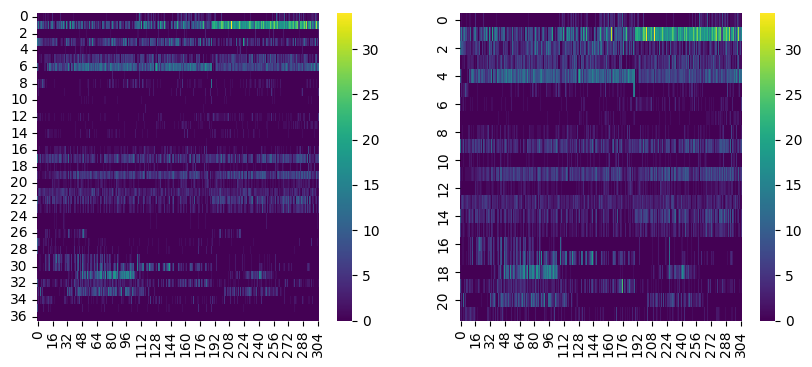

In [11]:
fig, ax = plt.subplots(figsize=(10,4), ncols=2)
sns.heatmap(data[0].T, ax=ax[0], cmap='viridis')
sns.heatmap(cleaned_data[0], ax=ax[1], cmap='viridis')

In [13]:
data_discretized = discretize_neural_data(cleaned_data[0], 'neuron')

(22, 306) neuron


100%|██████████| 22/22 [00:00<00:00, 939.57it/s]


In [ ]:


models = {
    'Lasso': LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)



In [18]:
X = data_discretized.T 

In [23]:
# Hyperparameters for decision tree
dt_param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Hyperparameters for logistic regression
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],   # Regularization strength
    'solver': ['liblinear', 'lbfgs'] # Different solvers for logistic regression
}

scoring = {'accuracy': 'accuracy', 'r2': make_scorer(r2_score)}


# Decision Tree with GridSearchCV
dt = DecisionTreeClassifier(random_state=42)
dt_grid_search = GridSearchCV(estimator=dt, param_grid=dt_param_grid, cv=kf, scoring=make_scorer(r2_score), refit=True)
dt_grid_search.fit(X, Y_true)
dt_best_model = dt_grid_search.best_estimator_

# Logistic Regression with GridSearchCV
lr = LogisticRegression(random_state=42, max_iter=1000)
dt_grid_search = GridSearchCV(estimator=dt, param_grid=dt_param_grid, cv=kf, scoring=make_scorer(r2_score), refit=True)
lr_grid_search.fit(X, Y_true)
lr_best_model = lr_grid_search.best_estimator_


In [25]:
# Evaluate Decision Tree
dt_scores = cross_val_score(dt_best_model, X, Y_true, cv=kf, scoring=make_scorer(r2_score))
print("Decision Tree Accuracy:", np.mean(dt_scores))

# Evaluate Logistic Regression
lr_scores = cross_val_score(lr_best_model, X, Y_true, cv=kf, scoring=make_scorer(r2_score))
print("Logistic Regression Accuracy:", np.mean(lr_scores))


Decision Tree Accuracy: 0.437891268845443
Logistic Regression Accuracy: 0.5571852307696228


In [36]:
performance_scores = {model_name: [] for model_name in models.keys()}

In [37]:
for i in range(1, X.shape[1] + 1):
    X_subset = X[:, :i]  # Subset of features up to the i-th feature
    
    for model_name, model in models.items():
        scores = cross_val_score(model, X_subset, Y_true, cv=kf, scoring=make_scorer(r2_score))
        performance_scores[model_name].append(np.mean(scores))
    
    # Optionally, print progress for each feature set size
    print(f"Evaluated {i} features")

Evaluated 1 features
Evaluated 2 features
Evaluated 3 features
Evaluated 4 features
Evaluated 5 features
Evaluated 6 features
Evaluated 7 features
Evaluated 8 features
Evaluated 9 features
Evaluated 10 features
Evaluated 11 features
Evaluated 12 features
Evaluated 13 features
Evaluated 14 features
Evaluated 15 features
Evaluated 16 features
Evaluated 17 features
Evaluated 18 features
Evaluated 19 features
Evaluated 20 features
Evaluated 21 features
Evaluated 22 features


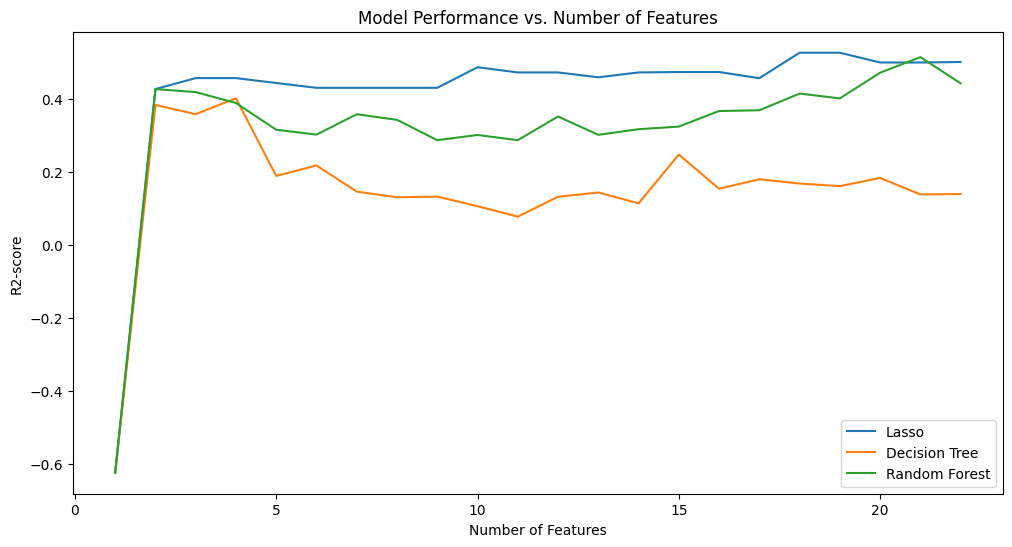

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for model_name, scores in performance_scores.items():
    plt.plot(range(1, X.shape[1] + 1), scores, label=model_name)

plt.xlabel("Number of Features")
plt.ylabel("R2-score")
plt.title("Model Performance vs. Number of Features")
plt.legend()
plt.show()


In [39]:
param_grids = {
    'Lasso': {
        'C': [0.01, 0.1, 1, 10, 100],   # Regularization strength
        'solver': ['liblinear', 'saga']
    },
    'Decision Tree': {
        'max_depth': [3, 5, 10, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, 10, None]
    }
}

In [ ]:
outer_kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Initialize scaler for MLP and Lasso, which are sensitive to feature scaling
scaler = StandardScaler()
X_scaled = X #scaler.fit_transform(X)
Y = Y_true

# Prepare dictionary to store results
nested_scores = {model_name: [] for model_name in param_grids.keys()}

# Outer loop: Cross-validation for evaluation
for i in range(1, X.shape[1] + 1):
    X_subset = X_scaled[:, :i]  # Use the first `i` features

    for model_name, param_grid in param_grids.items():
        if model_name == 'Lasso':
            model = LogisticRegression(penalty='l1', max_iter=1000, random_state=42)
        elif model_name == 'Decision Tree':
            model = DecisionTreeClassifier(random_state=42)
        elif model_name == 'Random Forest':
            model = RandomForestClassifier(random_state=42)
        
        # Inner loop: Hyperparameter tuning with GridSearchCV
        inner_cv = KFold(n_splits=3, shuffle=True, random_state=42)
        grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=inner_cv, scoring='accuracy')
        
        # Fit and evaluate the grid search within the outer cross-validation loop
        scores = cross_val_score(grid_search, X_subset, Y, cv=outer_kf, scoring='accuracy')
        nested_scores[model_name].append(np.mean(scores))
    
    print(f"Completed evaluation with {i} features")

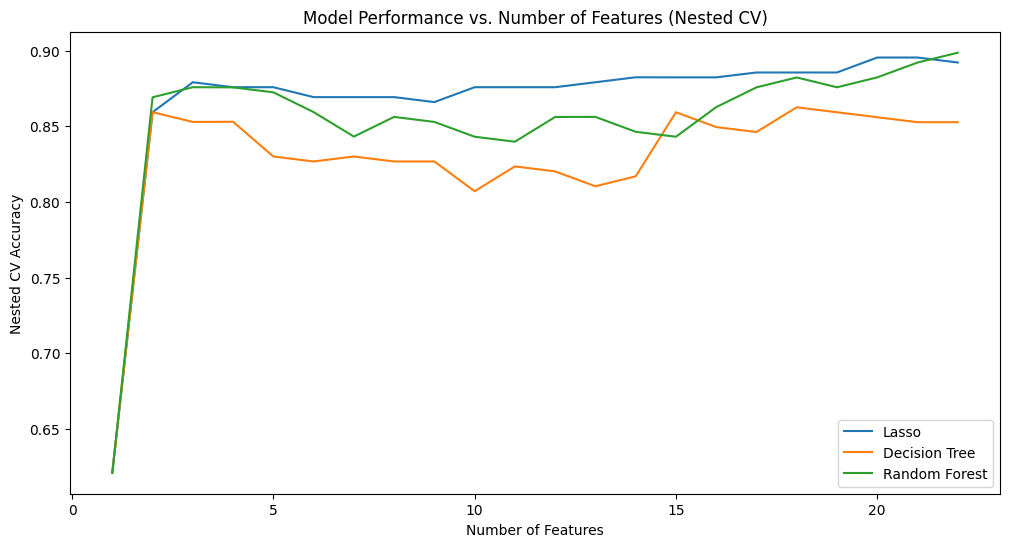

In [44]:
plt.figure(figsize=(12, 6))

for model_name, scores in nested_scores.items():
    plt.plot(range(1, X.shape[1] + 1), scores, label=model_name)

plt.xlabel("Number of Features")
plt.ylabel("Nested CV Accuracy")
plt.title("Model Performance vs. Number of Features (Nested CV)")
plt.legend()
plt.show()

In [46]:
from sklearn import linear_model as lm


In [72]:
estimator = lm.LogisticRegression

In [136]:
def run_decoding(Y, X, hyperparameter_opt=False):

    if hyperparameter_opt:
        return NotImplementedError
    
    model = LogisticRegression(penalty='l2', max_iter=1000, random_state=42)
    scoring = r2_score

    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    # now run three cv loops, for X[0], X[1] and X
    global_scores = []
    for idx in [0,1,[0,1]]:

        if idx==0 or idx==1:
            X_used = X[:, idx].reshape(-1,1)
        else:
            X_used = X[:, idx]
        
        scores = cross_val_score(model, X_used, Y, cv=kf, scoring=make_scorer(r2_score))
        global_scores.append(scores)
    global_scores = np.asarray(global_scores)
    return global_scores

<Axes: >

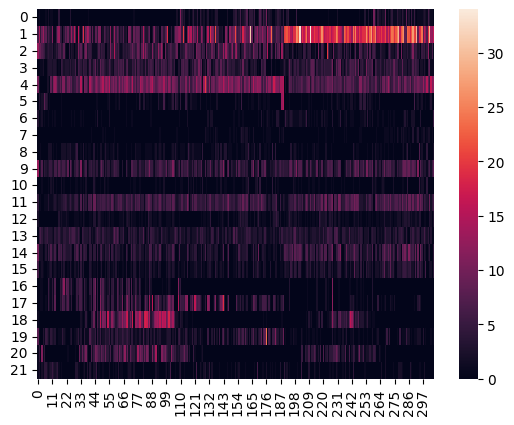

In [128]:

sns.heatmap(cleaned_data[0])

In [150]:
from tqdm import tqdm
import itertools

In [151]:
def generate_source_ids(number_of_neurons):
    combinations_neuronids=[]
    for x in itertools.combinations(range(number_of_neurons), 2):
        combinations_neuronids.append([x[0], x[1]])
    
    combinations_neuronids = np.asarray(combinations_neuronids)
    return combinations_neuronids

In [152]:
source_ids = generate_source_ids(X.shape[1])

<Axes: >

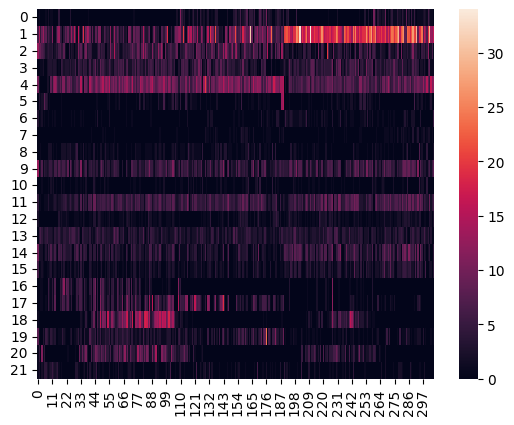

In [167]:
sns.heatmap(cleaned_data[0])

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
model_a = LogisticRegression(penalty='l2', max_iter=1000, random_state=42)
model_b = lm.Lasso()

scoring = r2_score

In [175]:
global_scores_a = [] 
global_scores_b = [] 

In [182]:
estimator = lm.Lasso
scoring = r2_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)
estimator_kwargs = {'tol': 0.0001, 'max_iter': 20000, 'fit_intercept': True}  # default args for decoder
model_b = estimator(**estimator_kwargs)


In [186]:

for idx in tqdm(range(source_ids.shape[0])):

    subset = source_ids[idx, :]
    X_subset = X[:, subset]  # Subset of features up to the i-th feature
    
    # print(np.mean(X_subset, axis=0))
    scores_a = cross_val_score(model_a, X_subset, Y_true, cv=kf, scoring=make_scorer(r2_score))
    scores_b = cross_val_score(model_b, X_subset, Y_true, cv=kf, scoring=make_scorer(r2_score))
    global_scores_a.append(np.mean(scores_a))
    global_scores_b.append(np.mean(scores_b))
    
    # Optionally, print progress for each feature set size

100%|██████████| 231/231 [00:06<00:00, 36.18it/s]


<Axes: ylabel='Density'>

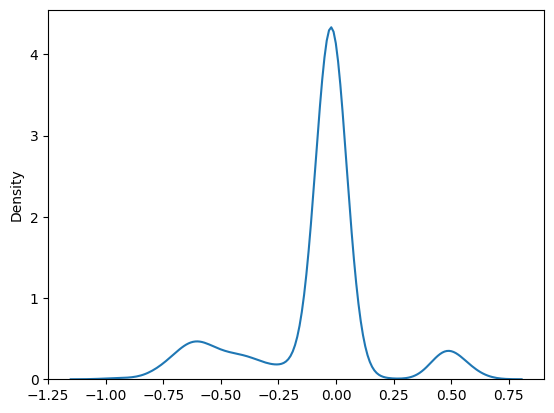

In [187]:
sns.kdeplot(global_scores_b)

In [192]:
np.mean(scores_a)

-0.6246818384318384

In [220]:
X1 = data_discretized[0,:]
X2 = data_discretized[1,:]

In [223]:
np.vstack([X1, X2]).T.shape

(306, 2)

In [224]:
X_subset[:,0].shape

(306,)

In [242]:
def run_decoding(Y, X, hyperparameter_opt=False):
    
    # estimator = lm.Lasso
    # estimator_kwargs = {'tol': 0.0001, 'max_iter': 20000, 'fit_intercept': True}  # default args for decoder
    # model = estimator(**estimator_kwargs)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    model = lm.LogisticRegression(penalty='l2', max_iter=1000, random_state=42)
    score = cross_val_score(model, X, Y, cv=kf, scoring=make_scorer(r2_score))
    return np.mean(score)

In [243]:
for idx in tqdm(range(source_ids.shape[0])):

    subset = source_ids[idx, :]
    X_subset = X[:, subset]  # Subset of features up to the i-th feature
    
    # print(np.mean(X_subset, axis=0))
    scores_a = cross_val_score(model_a, X_subset, Y_true, cv=kf, scoring=make_scorer(r2_score))
    scores_b = cross_val_score(model_b, X_subset, Y_true, cv=kf, scoring=make_scorer(r2_score))
    global_scores_a.append(np.mean(scores_a))
    global_scores_b.append(np.mean(scores_b))
    
    # Optionally, print progress for each feature set size

100%|██████████| 231/231 [00:04<00:00, 47.83it/s]


In [244]:
for idx in tqdm(range(len(source_ids)), desc="Running for all source_ids",leave=False):
        s1 = source_ids[idx][0]
        s2 = source_ids[idx][1]
        X1 = np.asarray(X[:, s1], dtype=np.int32)
        X2 = np.asarray(X[:, s2], dtype=np.int32)
        Y = np.asarray(Y_true, dtype=np.int32)
        X_prime = np.vstack([X1, X2]).T
        decoding_score = run_decoding(Y, X_prime)


In [237]:
X.shape

(306, 22)